<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/cross_validation_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cross-Validation and Hyperparameter Tuning**
### AIML - NIELIT Ropar
**Instructor:** Lovnish Verma, Project Engineer & Faculty, NIELIT Ropar

---

**What you will learn in this notebook:**
1. Why we need cross-validation
2. How K-Fold cross-validation works (with code)
3. Stratified K-Fold for imbalanced data
4. What hyperparameters are
5. Grid Search - trying every combination
6. Random Search - smarter, faster tuning
7. Comparing results and picking the best model


---

**Cross-validation (CV)** is a fundamental step in machine learning used to evaluate a model's performance and ensure it generalizes well to unseen data, rather than just memorizing the training set (overfitting).

**Here are the most widely used cross-validation techniques:**

### **1. K-Fold Cross-Validation**
This is the standard, go-to technique for most machine learning tasks.
* **How it works:** The dataset is shuffled and divided into $k$ equal-sized blocks (or "folds"). The model is trained on $k-1$ folds and tested on the remaining 1 fold. This process is repeated $k$ times, with each fold serving as the test set exactly once.
* **Pros:** Every data point gets to be in a test set exactly once, making the evaluation score highly reliable.
* **Use case:** General classification and regression tasks with moderately sized datasets.

### **2. Stratified K-Fold Cross-Validation**
A variation of standard K-Fold designed specifically for classification problems.
* **How it works:** It splits the data into $k$ folds, but it enforces that each fold contains roughly the same proportion of target class labels as the complete dataset.
* **Pros:** Prevents scenarios where a fold might contain only a single class, which would ruin the training/testing phase for that iteration.
* **Use case:** Highly recommended for **imbalanced datasets** (e.g., fraud detection, where 99% of transactions are legitimate and 1% are fraudulent).

### **3. Leave-One-Out Cross-Validation (LOOCV)**
This is an extreme version of K-Fold where $k$ equals the total number of samples ($N$) in the dataset.
* **How it works:** For a dataset with $N$ samples, the model trains on $N-1$ samples and tests on the single remaining sample. This is repeated $N$ times.
* **Pros:** Uses almost all the data for training, resulting in a model with low bias.
* **Cons:** Extremely computationally expensive. If you have 10,000 rows, you must train the model 10,000 times.
* **Use case:** Very small datasets where you cannot afford to hold out large chunks for testing.

### **4. Time Series Split (Rolling Cross-Validation)**
Standard CV techniques assume data is independent and identically distributed (I.I.D.). This assumption fails in time-series data, where looking at future data to predict past data causes "data leakage."
* **How it works:** The data is ordered chronologically. In the first iteration, it trains on the oldest data and tests on the next slice. In the next iteration, the training set expands to include the previous test slice, and tests on the next chronological slice.
* **Pros:** Respects the temporal order of data, ensuring you never train on the "future" to predict the "past."
* **Use case:** Stock market prediction, weather forecasting, sales forecasting.

### **5. Group K-Fold Cross-Validation**
Used when the dataset contains distinct, logically grouped data points, and you want to ensure that the same group does not appear in both the training and testing sets.
* **How it works:** Like K-Fold, but instead of splitting samples randomly, it splits based on a specified group identifier.
* **Pros:** Prevents data leakage across groups.
* **Use case:** Medical data (e.g., you have multiple X-rays from the same patient. You want the patient to be strictly in either the train or test set, otherwise, the model might just learn to recognize the patient's specific anatomy rather than the disease).

***


The major difference between Stratified K-Fold and Group K-Fold comes down to **what problem they are trying to solve** when splitting the data.

* **Stratified K-Fold** looks at your **Target Variable (Y)** to ensure class proportions are balanced.
* **Group K-Fold** looks at your **Input Data Source (X)** to prevent data leakage from related samples.

Here is a breakdown of how they differ in practice:

### 1. Stratified K-Fold: Solving "Class Imbalance"
This technique ensures that the ratio of the classes you are trying to predict remains identical across all training and testing folds.

* **The Problem it Solves:** Imagine you are building a model to detect a rare disease, where 90% of your dataset is "Healthy" and 10% is "Sick." If you use standard random splitting, one of your test folds might accidentally end up with 100% "Healthy" patients and 0 "Sick" patients. The model can't be evaluated properly on that fold.
* **The Solution:** Stratified K-Fold forces every single fold to maintain that exact 90/10 split.
* **Focus:** It groups by the **Label / Target Variable**.

### 2. Group K-Fold: Solving "Data Leakage"
This technique ensures that data points originating from the same source (the same "group") are kept strictly together. A group must be entirely in the training set or entirely in the testing set—never split between the two.

* **The Problem it Solves:** Imagine you have a medical dataset with 1,000 X-ray images, but they come from only 100 patients (10 X-rays per patient). If you use a standard split, Patient A might have 8 X-rays in the training set and 2 in the test set.
    * *The Danger:* The model might just learn to recognize Patient A's unique bone structure or jewelry, rather than actually learning to detect the disease. When it sees Patient A in the test set, it guesses correctly for the wrong reasons. This is a massive data leak.
* **The Solution:** Group K-Fold guarantees that all 10 X-rays from Patient A will either be used for training *or* for testing, but never both.
* **Focus:** It groups by an **Identifier / Feature** (e.g., Patient ID, Session ID, Device ID).

---

### Summary Comparison

| Feature | Stratified K-Fold | Group K-Fold |
| :--- | :--- | :--- |
| **Primary Goal** | Maintain equal class distribution. | Prevent data leakage across related samples. |
| **What dictates the split?** | The Target Label (e.g., `is_fraud`, `has_disease`). | A Group ID (e.g., `user_id`, `patient_id`, `session_id`). |
| **Use Case Example** | Credit card fraud detection (where fraud is only 0.1% of data). | Voice recognition (where you have multiple audio clips from the same speaker). |
| **Can they be combined?** | Yes. Scikit-learn offers `StratifiedGroupKFold` if you have imbalanced data *and* overlapping groups. | Yes. |



---



## Step 0: Install and Import Everything

We will use the **Iris dataset** (flowers with 3 classes) and a **Random Forest** classifier throughout this notebook. Both are beginner-friendly and well understood.

In [ ]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Dataset
from sklearn.datasets import load_iris

# Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Cross-validation tools
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

# Metrics
from sklearn.metrics import accuracy_score

print("All libraries imported successfully!")

All libraries imported successfully!


---

## Part 1: Why Cross-Validation?

### The Problem with a Single Train-Test Split

When we do a simple 80/20 split, our accuracy score depends on **which samples happened to land in the test set by chance**. If lucky samples end up in the test set, accuracy is high. If hard samples end up there, accuracy is low.

This makes evaluation **unreliable**.

**Cross-validation solves this** by rotating through different *test sets* and averaging the results.

In [ ]:
# Load the Iris dataset
iris = load_iris()
X = iris.data      # Features: sepal length, sepal width, petal length, petal width
y = iris.target    # Labels: 0=Setosa, 1=Versicolor, 2=Virginica

print(f"Dataset shape: {X.shape}")
print(f"Classes: {iris.target_names}")
print(f"Samples per class: {np.bincount(y)}")

Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Samples per class: [50 50 50]


In [ ]:
# ── Demonstrate the problem with a single split ──

model = RandomForestClassifier(n_estimators=10, random_state=None)

# Run the same model with 5 different random splits
print("Accuracy with 5 different random train-test splits:")
print("-" * 45)

scores = []
for seed in [1, 2, 3, 4, 5]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    scores.append(acc)
    print(f"  Split {seed}: {acc:.4f}")

print("-" * 45)
print(f"  Range: {min(scores):.4f} → {max(scores):.4f}  (varies by {(max(scores)-min(scores))*100:.1f}%)")
print("\nConclusion: A single split gives inconsistent results!")

Accuracy with 5 different random train-test splits:
---------------------------------------------
  Split 1: 0.9667
  Split 2: 0.9667
  Split 3: 0.9667
  Split 4: 0.9333
  Split 5: 0.9000
---------------------------------------------
  Range: 0.9000 → 0.9667  (varies by 6.7%)

Conclusion: A single split gives inconsistent results!


---

## Part 2: K-Fold Cross-Validation

### How It Works

```
K = 5, Dataset = 150 samples

Fold 1: [TEST ] [train] [train] [train] [train]  → score1
Fold 2: [train] [TEST ] [train] [train] [train]  → score2
Fold 3: [train] [train] [TEST ] [train] [train]  → score3
Fold 4: [train] [train] [train] [TEST ] [train]  → score4
Fold 5: [train] [train] [train] [train] [TEST ]  → score5

Final Score = mean(score1, score2, score3, score4, score5)
```

Every sample gets tested **exactly once**. The result is stable and trustworthy.

In [ ]:
# Manual K-Fold to understand what happens inside

model = RandomForestClassifier(n_estimators=10, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_scores = []

print("K-Fold Cross-Validation (K=5)")
print("-" * 50)

for fold_num, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    # Split data using fold indices
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Train and evaluate
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    fold_scores.append(acc)

    print(f"  Fold {fold_num}: Train size={len(train_idx)}, Test size={len(test_idx)}, Accuracy={acc:.4f}")

print("-" * 50)
print(f"  Mean Accuracy : {np.mean(fold_scores):.4f}")
print(f"  Std Deviation : {np.std(fold_scores):.4f}  (lower is more stable)")

K-Fold Cross-Validation (K=5)
--------------------------------------------------
  Fold 1: Train size=120, Test size=30, Accuracy=1.0000
  Fold 2: Train size=120, Test size=30, Accuracy=0.9667
  Fold 3: Train size=120, Test size=30, Accuracy=0.9333
  Fold 4: Train size=120, Test size=30, Accuracy=0.9333
  Fold 5: Train size=120, Test size=30, Accuracy=0.9333
--------------------------------------------------
  Mean Accuracy : 0.9533
  Std Deviation : 0.0267  (lower is more stable)


In [ ]:
# Shortcut using cross_val_score (does the same thing in one line)

model = RandomForestClassifier(n_estimators=10, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print("cross_val_score result:")
print(f"  Scores per fold : {scores}")
print(f"  Mean Accuracy   : {scores.mean():.4f}")
print(f"  Std Deviation   : {scores.std():.4f}")

cross_val_score result:
  Scores per fold : [1.         0.96666667 0.93333333 0.93333333 0.93333333]
  Mean Accuracy   : 0.9533
  Std Deviation   : 0.0267


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=10, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

print("CV Results:")
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Std Dev     : {scores.std():.4f}")

CV Results:
Mean Accuracy: 0.9583
Std Dev     : 0.0373


In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("\nFinal Test Accuracy:")
print(f"{accuracy_score(y_test, y_pred):.4f}")


Final Test Accuracy:
0.9000


---

## Part 3: Stratified K-Fold

**Problem with regular K-Fold:** If your dataset is imbalanced (e.g., 80% class A, 20% class B), some folds might have very few or no samples of a rare class.

**Stratified K-Fold** ensures every fold has the **same class proportion** as the full dataset.

> **Rule of thumb:** Always use Stratified K-Fold for classification tasks.

In [ ]:
# Stratified K-Fold

model = RandomForestClassifier(n_estimators=10, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Stratified K-Fold — Class distribution per fold")
print("-" * 55)

stratified_scores = []

for fold_num, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    counts = np.bincount(y_test)   # class counts in this test fold
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    stratified_scores.append(acc)

    print(f"  Fold {fold_num}: Classes in test = {counts}, Accuracy = {acc:.4f}")

print("-" * 55)
print(f"  Mean Accuracy : {np.mean(stratified_scores):.4f}")
print(f"  Std Deviation : {np.std(stratified_scores):.4f}")
print("\nNotice: each fold has equal class representation (50 each → 10 per fold)")

Stratified K-Fold — Class distribution per fold
-------------------------------------------------------
  Fold 1: Classes in test = [10 10 10], Accuracy = 1.0000
  Fold 2: Classes in test = [10 10 10], Accuracy = 0.9667
  Fold 3: Classes in test = [10 10 10], Accuracy = 0.9333
  Fold 4: Classes in test = [10 10 10], Accuracy = 0.9667
  Fold 5: Classes in test = [10 10 10], Accuracy = 0.9000
-------------------------------------------------------
  Mean Accuracy : 0.9533
  Std Deviation : 0.0340

Notice: each fold has equal class representation (50 each → 10 per fold)


---

## Part 4: What Are Hyperparameters?

A model has two kinds of parameters:

| Type | Who sets it? | Example |
|------|--------------|---------|
| **Parameters** | Learned from data during training | weights in neural network, split thresholds in decision tree |
| **Hyperparameters** | Set by YOU before training | number of trees, max depth, learning rate |

**Hyperparameter tuning** = finding the best values for these settings to maximize model performance.

### Common Hyperparameters of RandomForestClassifier

| Hyperparameter | What it controls | Typical range |
|----------------|-----------------|---------------|
| `n_estimators` | Number of trees | 10 – 500 |
| `max_depth` | How deep each tree grows | 2 – 20, or None |
| `min_samples_split` | Min samples needed to split a node | 2 – 20 |
| `max_features` | Features to consider at each split | 'sqrt', 'log2' |

---

## Part 5: Grid Search CV

**Grid Search** tries **every possible combination** of the hyperparameter values you provide.

If you give 3 values for `n_estimators` and 3 for `max_depth` → it tries 3 × 3 = **9 combinations**.

For each combination it runs full cross-validation → picks the best one.

> **Downside:** Can be slow when you have many hyperparameters or large datasets.

In [ ]:
# Grid Search CV

# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [10, 50, 100],       # 3 options
    'max_depth':    [None, 3, 5],         # 3 options
    'min_samples_split': [2, 5]           # 2 options
}                                         # Total combinations: 3 × 3 × 2 = 18

model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,                  # 5-fold cross-validation inside
    scoring='accuracy',
    n_jobs=-1,             # use all CPU cores
    verbose=1
)

grid_search.fit(X, y)

print("\nGrid Search Results")
print("-" * 40)
print(f"Best Parameters  : {grid_search.best_params_}")
print(f"Best CV Accuracy : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Grid Search Results
----------------------------------------
Best Parameters  : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 10}
Best CV Accuracy : 0.9667


In [ ]:
# View all combinations tested

results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[['param_n_estimators', 'param_max_depth',
                          'param_min_samples_split', 'mean_test_score', 'rank_test_score']]
results_df = results_df.sort_values('rank_test_score').reset_index(drop=True)

print("Top 10 combinations:")
print(results_df.head(10).to_string(index=False))

Top 10 combinations:
 param_n_estimators param_max_depth  param_min_samples_split  mean_test_score  rank_test_score
                 10            None                        2         0.966667                1
                 50            None                        2         0.966667                1
                100            None                        2         0.966667                1
                 50            None                        5         0.966667                1
                 10               3                        2         0.966667                1
                100            None                        5         0.966667                1
                 50               3                        2         0.966667                1
                100               3                        2         0.966667                1
                100               5                        2         0.966667                1
                 10          

---

## Part 6: Randomized Search CV

**Random Search** doesn't try every combination. Instead, it **randomly samples** from the parameter space for a fixed number of iterations.

**Why use it?**
- Much faster than Grid Search when the parameter space is large
- Often finds nearly equally good results in a fraction of the time
- Allows you to search over continuous distributions (e.g., learning rate from 0.001 to 1.0)

> **Rule of thumb:** Start with Random Search to narrow down the range, then use Grid Search to fine-tune.

In [ ]:
from scipy.stats import randint

# Randomized Search CV

# Define a larger search space (distributions, not fixed lists)
param_dist = {
    'n_estimators':      randint(10, 200),       # randomly pick from 10 to 200
    'max_depth':         [None, 2, 3, 5, 7, 10],
    'min_samples_split': randint(2, 15),          # randomly pick from 2 to 15
    'max_features':      ['sqrt', 'log2']
}

model = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,             # try only 20 random combinations
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X, y)

print("\nRandomized Search Results")
print("-" * 40)
print(f"Best Parameters  : {random_search.best_params_}")
print(f"Best CV Accuracy : {random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Randomized Search Results
----------------------------------------
Best Parameters  : {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 12, 'n_estimators': 81}
Best CV Accuracy : 0.9667


---

## Part 7: Comparing All Approaches

Let's put all results side by side to see the full picture.

     FINAL COMPARISON OF ALL APPROACHES
  Baseline (default params)  : 0.9667
  After Grid Search CV       : 0.9667
  After Randomized Search CV : 0.9667


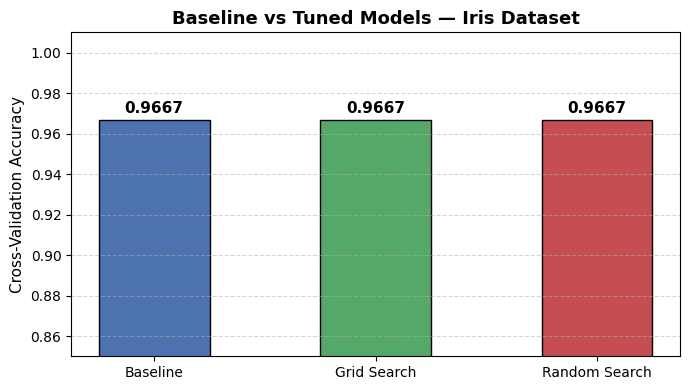

In [ ]:
# Baseline: default model with no tuning
baseline = RandomForestClassifier(random_state=42)
baseline_score = cross_val_score(baseline, X, y, cv=5, scoring='accuracy').mean()

# Summary Table
print("=" * 55)
print("     FINAL COMPARISON OF ALL APPROACHES")
print("=" * 55)
print(f"  Baseline (default params)  : {baseline_score:.4f}")
print(f"  After Grid Search CV       : {grid_search.best_score_:.4f}")
print(f"  After Randomized Search CV : {random_search.best_score_:.4f}")
print("=" * 55)

# Bar Chart
labels  = ['Baseline', 'Grid Search', 'Random Search']
scores  = [baseline_score, grid_search.best_score_, random_search.best_score_]
colors  = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, scores, color=colors, width=0.5, edgecolor='black')

# Add value labels on top of bars
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{score:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0.85, 1.01)
ax.set_ylabel('Cross-Validation Accuracy', fontsize=11)
ax.set_title('Baseline vs Tuned Models — Iris Dataset', fontsize=13, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---

## Part 8: Using the Best Model on New Data

Once you have found the best parameters, use `best_estimator_` — this is the trained model with the winning configuration.

In [ ]:
# Final Evaluation on a held-out test set

# Hold out 20% before any tuning (good practice in real projects)
X_train_full, X_test_final, y_train_full, y_test_final = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Get the best model from Grid Search
best_model = grid_search.best_estimator_

# Evaluate on the final held-out test set
y_pred = best_model.predict(X_test_final)
final_acc = accuracy_score(y_test_final, y_pred)

print("Best Parameters:", grid_search.best_params_)
print(f"Final Test Set Accuracy: {final_acc:.4f}")
print("\nPredictions vs Actual:")
for pred, actual in zip(y_pred[:10], y_test_final[:10]):
    status = '✓' if pred == actual else '✗'
    print(f"  Predicted: {iris.target_names[pred]:12s}  Actual: {iris.target_names[actual]:12s}  {status}")

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 10}
Final Test Set Accuracy: 1.0000

Predictions vs Actual:
  Predicted: setosa        Actual: setosa        ✓
  Predicted: virginica     Actual: virginica     ✓
  Predicted: versicolor    Actual: versicolor    ✓
  Predicted: versicolor    Actual: versicolor    ✓
  Predicted: setosa        Actual: setosa        ✓
  Predicted: versicolor    Actual: versicolor    ✓
  Predicted: setosa        Actual: setosa        ✓
  Predicted: setosa        Actual: setosa        ✓
  Predicted: virginica     Actual: virginica     ✓
  Predicted: versicolor    Actual: versicolor    ✓


---

## Summary

| Concept | What it does | When to use |
|---------|-------------|-------------|
| **K-Fold CV** | Rotates test folds for stable accuracy estimate | Always, instead of single split |
| **Stratified K-Fold** | Ensures balanced class distribution in each fold | Classification tasks (especially imbalanced) |
| **Grid Search CV** | Exhaustive search over all combinations | Small parameter grids |
| **Randomized Search CV** | Random sampling over parameter space | Large grids, limited compute |

### Typical Workflow in a Real Project

```
1. Load and explore data
2. Set aside a final test set (hold-out)
3. Use Stratified K-Fold CV on training data
4. Run Randomized Search to find good region
5. Run Grid Search to fine-tune in that region
6. Evaluate best_estimator_ on the final test set (once!)
7. Report final_test_accuracy as your model's performance
```

---
**NIELIT Ropar | AIML in Collabaration with IIT Ropar**  
Prepared by: Lovnish Verma | lovnishverma.in | @lovnishverma